# **Практическая работа №7. Random forest**

## **Задание 1. Обучите классификатор Random Forest для решения задачи бинарной классификации: для каждого человека научиться предсказывать, выживет ли он при крушении Титаника.**



Ссылка на датасет: https://www.kaggle.com/c/titanic/data

### 1. Устанавливаем зависимости

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 2. Импортируем датасет

In [52]:
# !wget 'https://drive.google.com/uc?export=download&id=1cLiYMd5YSpfJn5ajneHtin55i79KU7sB' -O test.csv
# !wget 'https://drive.google.com/uc?export=download&id=1oDzBtqrXFDnc4ABbAi5hy9UXXT5uVdbD' -O train.csv

In [53]:
!gdown 1cLiYMd5YSpfJn5ajneHtin55i79KU7sB -O test.csv
!gdown 1oDzBtqrXFDnc4ABbAi5hy9UXXT5uVdbD -O train.csv

"gdown" �� ���� ����७��� ��� ���譥�
��������, �ᯮ��塞�� �ணࠬ��� ��� ������ 䠩���.
"gdown" �� ���� ����७��� ��� ���譥�
��������, �ᯮ��塞�� �ணࠬ��� ��� ������ 䠩���.


### 3. Производим разведовательный анализ данных


Получим представление о данных в датасете:

In [54]:
df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [55]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [56]:
test_df.info()
test_df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    str    
 3   Sex          418 non-null    str    
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    str    
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     str    
 10  Embarked     418 non-null    str    
dtypes: float64(2), int64(4), str(5)
memory usage: 36.1 KB


,PassengerId,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,3.000000,76.000000,8.000000,9.000000,512.329200


### 4. Сформируем обучающую и тестовую выборки:


In [57]:
from sklearn.model_selection import train_test_split

df = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True)
df.drop('Cabin', axis=1, inplace=True)
df['Age'].fillna(df['Age'].mean(), inplace=True)

X_train, X_test, y_train, y_test = train_test_split(df.drop('Survived', axis=1), df['Survived'], test_size = 0.33, random_state = 42)
X_train.shape, X_test.shape

C:\Users\user\AppData\Local\Temp\ipykernel_7928\3233024665.py:5: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Age'].fillna(df['Age'].mean(), inplace=True)


((596, 11), (295, 11))

### 5. Feature Engineering

Поработаем с признаками, выделим важные, изменим форму их представления (при надобности)

In [58]:
X_train2 = X_train.drop(["Name", "Ticket", "PassengerId"], axis=1)
X_test2 = X_test.drop(["Name", "Ticket", "PassengerId"], axis=1)

# работа с признаками была проведена в предыдущем пункте

print(X_train2.shape)
display(X_train2.info()) # нет ли пустых объектов 
X_train2.head()

(596, 8)
<class 'pandas.DataFrame'>
Index: 596 entries, 6 to 102
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Pclass      596 non-null    int64  
 1   Age         478 non-null    float64
 2   SibSp       596 non-null    int64  
 3   Parch       596 non-null    int64  
 4   Fare        596 non-null    float64
 5   Sex_male    596 non-null    bool   
 6   Embarked_Q  596 non-null    bool   
 7   Embarked_S  596 non-null    bool   
dtypes: bool(3), float64(2), int64(3)
memory usage: 29.7 KB


None

,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
6,1,54.0,0,0,51.8625,True,False,True
718,3,NaN,0,0,15.5000,True,True,False
685,2,25.0,1,2,41.5792,True,False,False
73,3,26.0,1,0,14.4542,True,False,False
882,3,22.0,0,0,10.5167,False,False,True


Пустых объектов нету, продолжаем

### 6. Построение базовой модели:

In [59]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=1)
model.fit(X_train2, y_train)
y_pred = model.predict(X_test2)

### 7. Оценка точности модели:

#### 7.1. Напишите функцию, принимающую на вход аргументы y_pred, y_test и выполняющую визуализацию матрицы ошибок и отчета классификации

In [60]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report


def vis_cr_me(y_pred, y_test):
  cm = confusion_matrix(y_test, y_pred)
  plt.figure(figsize=(8, 6))
  sns.heatmap(cm, annot=True, fmt=".0f", cmap='Blues')
  plt.title('Матрица ошибок')
  plt.xlabel('Предсказанные')
  plt.ylabel('Реальные')
  plt.show()
  print(classification_report(y_test, y_pred))

#### 7.2. Оцените точность модели:

(295,) (295,)


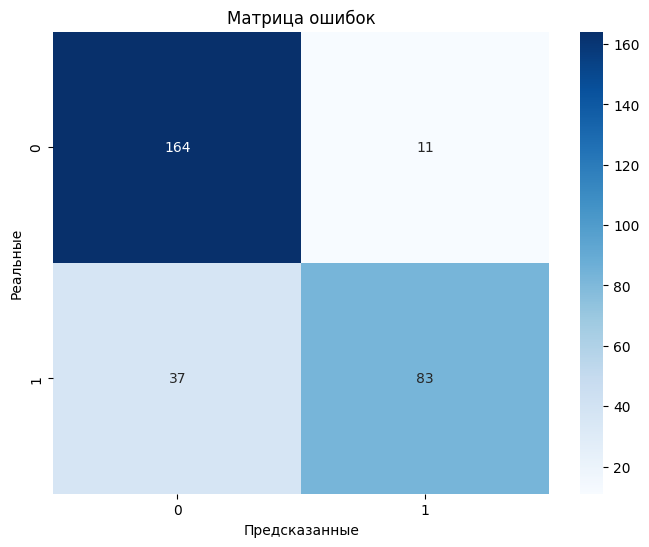

              precision    recall  f1-score   support

           0       0.82      0.94      0.87       175
           1       0.88      0.69      0.78       120

    accuracy                           0.84       295
   macro avg       0.85      0.81      0.82       295
weighted avg       0.84      0.84      0.83       295



In [61]:
print(y_pred.shape, y_test.shape)
vis_cr_me(y_pred, y_test)

Модель хорошо предсказыват выживших, но пропускает реально выживших

### 8. Тюнинг гиперпараметров модели:

#### RandomSearchCV

In [62]:
from sklearn.model_selection import RandomizedSearchCV

max_depth = [int(i) for i in np.linspace(start=1, stop=80, num=8)]
param_grid = {
    'n_estimators': [int(x) for x in np.linspace(start=10, stop=300, num=8)],
    'max_leaf_nodes': [int(i) for i in np.linspace(start=2, stop=50, num=8)],
    'max_depth': max_depth
}
rf_rcv = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grid,
    n_iter=100,
    scoring='accuracy',
    cv=5,
    verbose=0,
    random_state=42,
    n_jobs=-1
)

rf_rcv.fit(X_train2, y_train)

rcv_best_params = rf_rcv.best_params_
print(f"Лучшие параметры:")
for key, value in rcv_best_params.items():
    print(f"{key}: {value}")

Лучшие параметры:
n_estimators: 300
max_leaf_nodes: 22
max_depth: 46


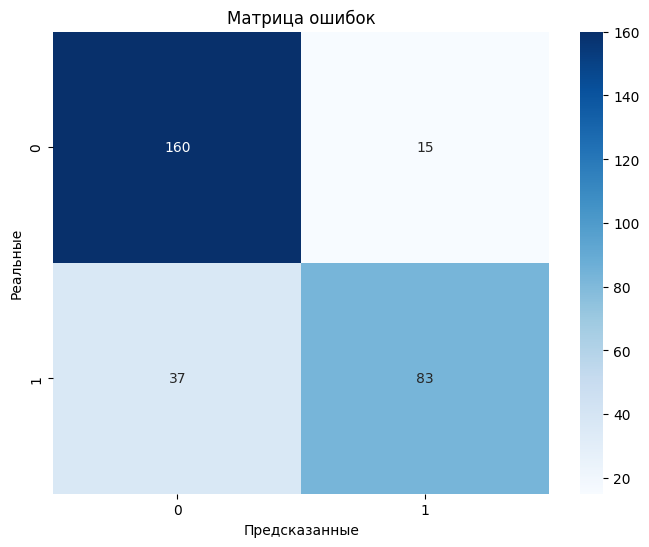

              precision    recall  f1-score   support

           0       0.81      0.91      0.86       175
           1       0.85      0.69      0.76       120

    accuracy                           0.82       295
   macro avg       0.83      0.80      0.81       295
weighted avg       0.83      0.82      0.82       295



In [63]:
rf_rcv.fit(X_train2, y_train)
y_pred = rf_rcv.predict(X_test2)
vis_cr_me(y_pred, y_test)

В данном случае работает малость хуже, чем обычная модель

#### GridSearchCV

In [67]:
from sklearn.model_selection import GridSearchCV

if rcv_best_params['n_estimators'] >= 4:
  n_estimators = [int(x) for x in range(rcv_best_params['n_estimators']-3, rcv_best_params['n_estimators']+4)]
else:
  n_estimators = [int(x) for x in range(1, 10)]
if rcv_best_params['max_leaf_nodes'] >= 5:
  max_leaf_nodes = [int(i) for i in range(rcv_best_params['max_leaf_nodes']-3, rcv_best_params['max_leaf_nodes']+4)]
else:
  max_leaf_nodes = [int(i) for i in range(2, 10)]
if ((rcv_best_params['max_depth']) and  (rcv_best_params['max_depth'] is not None)) >= 4:
  max_depth = [int(x) for x in range(rcv_best_params['max_depth']-3, rcv_best_params['max_depth']+4)]
else:
  max_depth = [int(x) for x in range(1, 10)]

random_grid = {
    'n_estimators': n_estimators,
    'max_leaf_nodes': max_leaf_nodes,
    'max_depth': max_depth
}

rf_cv = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring="accuracy",
    cv=5,
    n_jobs=-1
)

rf_cv.fit(X_train2, y_train)

best_params = rf_cv.best_params_
best_model = rf_cv.best_estimator_
print(f"Лучшие параметры:")
for key, value in best_params.items():
    print(f"{key}: {value}")

Лучшие параметры:
max_depth: 23
max_leaf_nodes: 22
n_estimators: 300


### 9. Комплексная оценка точности лучшей модели:

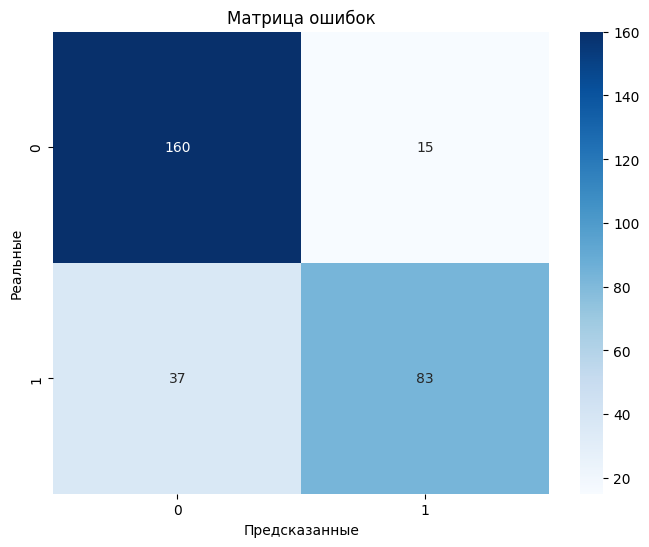

              precision    recall  f1-score   support

           0       0.81      0.91      0.86       175
           1       0.85      0.69      0.76       120

    accuracy                           0.82       295
   macro avg       0.83      0.80      0.81       295
weighted avg       0.83      0.82      0.82       295



In [68]:
best_model.fit(X_train2, y_train)
y_pred = best_model.predict(X_test2)
vis_cr_me(y_pred, y_test)

Также работает малость хуже, чем обычная модель

## **Задание 2. Решите задачу из предыдущего пункта используя другие, ранее пройденные классификаторы. Сравните их точность предсказания с Random Forest**

In [69]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X_train2 = X_train2.fillna(X_train2.mean())
X_test2 = X_test2.fillna(X_train2.mean())  # заполняем тест средним из train

models = {'lr': LogisticRegression(random_state=1, max_iter=1000),
          'knn': KNeighborsClassifier(),
          'dt': DecisionTreeClassifier(random_state=1)}

for name, model in models.items():
    model.fit(X_train2, y_train)
    y_pred = model.predict(X_test2)

    acc = accuracy_score(y_test, y_pred)
    print(f"\n{name}:")
    print(f"  Accuracy:  {acc:.4f}")


lr:
  Accuracy:  0.8136

knn:
  Accuracy:  0.6983

dt:
  Accuracy:  0.7627


## **Задание 2.1. Реализуйте функцию, для взаимодействия с обученной Вами моделью**



* Функция должна принимать на вход обученную модель классификатора;

* После вызова функции, у пользователя через консоль запрашиваются значения признаков. При запросе значений нужно вывести пояснения о типе и диапазоне возможных значений. Также реализуйте обработку исключений;

* После ввода значений для всех признаков в консоль, выводится результат работы классификатора.

In [ ]:
def predictor(model): # модель с уже выполненным fit
  res = {}

  while True:
    inp = int(input("Класс пассажира (1-3): "))
    if inp in range(1,4):
      res['Pclass'] = inp
      break
    else:
      print('Введено некорректное значение')

  res['Age'] = int(input("Возраст (0-inf): "))
  res['SibSp'] = int(input("Количество партнеров/братьев/сестер на борту (0-inf): "))
  res['Parch'] = int(input("Кол-во родных родителей/детей на борту (0-inf): "))
  res['Fare'] = int(input("Плата за проезд (0-inf): "))

  while True:
    inp = input("Пол (male/female): ")
    if inp == 'male':
      res['Sex_male'] = True
      break
    elif inp == 'female':
      res['Sex_male'] = False
      break
    else:
      print('Введено некорректное значение')

  while True:
    inp = input("Из какого города отправились (S/C/Q): ")
    if inp == 'S':
      res['Embarked_Q'] = False
      res['Embarked_S'] = True
      break
    elif inp == 'C':
      res['Embarked_Q'] = False
      res['Embarked_S'] = False
      break
    elif inp == 'Q':
      res['Embarked_Q'] = True
      res['Embarked_S'] = False
      break
    else:
      print('Введено некорректное значение')

  for key, value in res.items():
    print(f"{key}: {value}")

  res = pd.DataFrame([res])
  pred = model.predict(res)
  if pred[0] == 0:
    print('\nМодель предсказала, что вы не выживете...')
  else:
    print('\nМодель предсказала, что вы выживете!')

predictor(model)

Pclass: 1
Age: 100
SibSp: 8
Parch: 8
Fare: 1000000000
Sex_male: True
Embarked_Q: False
Embarked_S: True

Модель предсказал, что вы не выживете...


## **Задание 3. Решите задачу регрессии, используя [RandomForestRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html).**

**ОБЯЗАТЕЛЬНО ОСУЩЕСТВИТЕ ПОДБОР ОПТИМАЛЬНЫХ ПАРАМЕТРОВ, ИСПОЛЬЗУЯ RandomSearchCV и GridSearchCV**



* Для выполнения данного задания можете использовать **любой датасет**



Ссылка на один из сайтов-источников датасетов: https://www.kaggle.com/datasets?tags=14203-Regression

ДАТАСЕТ ПОКЕМОНОВ

In [104]:
import kagglehub
import pandas as pd

dataset_path = kagglehub.dataset_download("darkmatternet/ultimate-pokmon-dataset-2025")
print(dataset_path)
df = pd.read_csv(f"{dataset_path}/pokemon_complete_2025.csv")

C:\Users\user\.cache\kagglehub\datasets\darkmatternet\ultimate-pokmon-dataset-2025\versions\1


In [105]:
pd.set_option('display.max_columns', None)
df.head()

,pokedex_id,name,genus,generation,type_1,type_2,num_types,hp,attack,defense,sp_attack,sp_defense,speed,base_stat_total,height_m,weight_kg,base_experience,ability_1,ability_2,hidden_ability,color,shape,habitat,growth_rate,egg_groups,is_legendary,is_mythical,is_baby,capture_rate,base_happiness,hatch_counter,gender_rate,description,sprite_url,is_dual_type,bmi,attack_defense_ratio,physical_total,special_total,offensive_total,defensive_total,gender_distribution,stat_tier
0,1,bulbasaur,Seed Pokémon,I,grass,poison,2,45,49,49,65,65,45,318,0.7,6.9,64,overgrow,NaN,chlorophyll,green,quadruped,grassland,medium-slow,"monster, plant",False,False,False,45,70,20,1,A strange seed was planted on its back at birt...,https://raw.githubusercontent.com/PokeAPI/spri...,True,14.1,1.00,98,130,159,159,88% Male / 12% Female,Below Average (300-399)
1,2,ivysaur,Seed Pokémon,I,grass,poison,2,60,62,63,80,80,60,405,1.0,13.0,142,overgrow,NaN,chlorophyll,green,quadruped,grassland,medium-slow,"monster, plant",False,False,False,45,70,20,1,"When the bulb on its back grows large, it appe...",https://raw.githubusercontent.com/PokeAPI/spri...,True,13.0,0.98,125,160,202,203,88% Male / 12% Female,Average (400-499)
2,3,venusaur,Seed Pokémon,I,grass,poison,2,80,82,83,100,100,80,525,2.0,100.0,236,overgrow,NaN,chlorophyll,green,quadruped,grassland,medium-slow,"monster, plant",False,False,False,45,70,20,1,The plant blooms when it is absorbing solar en...,https://raw.githubusercontent.com/PokeAPI/spri...,True,25.0,0.99,165,200,262,263,88% Male / 12% Female,Strong (500-599)
3,4,charmander,Lizard Pokémon,I,fire,NaN,1,39,52,43,60,50,65,309,0.6,8.5,62,blaze,NaN,solar-power,red,upright,mountain,medium-slow,"monster, dragon",False,False,False,45,70,20,1,"Obviously prefers hot places. When it rains, s...",https://raw.githubusercontent.com/PokeAPI/spri...,False,23.6,1.21,95,110,177,132,88% Male / 12% Female,Below Average (300-399)
4,5,charmeleon,Flame Pokémon,I,fire,NaN,1,58,64,58,80,65,80,405,1.1,19.0,142,blaze,NaN,solar-power,red,upright,mountain,medium-slow,"monster, dragon",False,False,False,45,70,20,1,"When it swings its burning tail, it elevates t...",https://raw.githubusercontent.com/PokeAPI/spri...,False,15.7,1.10,122,145,224,181,88% Male / 12% Female,Average (400-499)


In [106]:
print(df.dtypes)

pokedex_id                int64
name                        str
genus                       str
generation                  str
type_1                      str
type_2                      str
num_types                 int64
hp                        int64
attack                    int64
defense                   int64
sp_attack                 int64
sp_defense                int64
speed                     int64
base_stat_total           int64
height_m                float64
weight_kg               float64
base_experience           int64
ability_1                   str
ability_2                   str
hidden_ability              str
color                       str
shape                       str
habitat                     str
growth_rate                 str
egg_groups                  str
is_legendary               bool
is_mythical                bool
is_baby                    bool
capture_rate              int64
base_happiness            int64
hatch_counter             int64
gender_r

Так как стоит задача регрессии нас интересует интовое значение целевой перменной. В качестве целевой перменной я выбрал base_stat_total (BST), также приведу формуле по которой она вычисляется: BST = HP + Atk + Def + SpA + SpD + Spe.

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

In [108]:
df_clean = df.dropna(subset=['base_stat_total']).copy()  # удаляем пропуски в целевой переменной
y = df_clean['base_stat_total']

Выберем признаки: исключим идентификаторы и целевую переменную, а также то, из чего формируется BST (HP + Atk + Def + SpA + SpD + Spe) ради интереса. (В противном случае если их оставить, то модель быстро приблизится почти к идеальному результату, так как задача была бы очень простая)

In [111]:
X = df_clean.drop([
    'pokedex_id', 'name', 'description', 'sprite_url', # идентификаторы
    'hp', 'attack', 'defense', 'sp_attack', 'sp_defense', 'speed',  # статы
    'base_stat_total'  # целевая переменная
], axis=1, errors='ignore')

for col in X.select_dtypes(include='object').columns:
    le = LabelEncoder()
    X[col] = X[col].fillna('Unknown').astype(str)
    X[col] = le.fit_transform(X[col].astype(str))

C:\Users\user\AppData\Local\Temp\ipykernel_7928\1342812583.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in X.select_dtypes(include='object').columns:


In [113]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (768, 32), Test: (257, 32)


In [ ]:
base_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
base_model.fit(X_train, y_train)

y_pred_base = base_model.predict(X_test)

print(f"Метрики базовой модели:")
print(f"MAE:  {mean_absolute_error(y_test, y_pred_base):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_base)):.2f}")
print(f"R²:   {r2_score(y_test, y_pred_base):.4f}")

Метрики базовой модели:
MAE:  4.98
RMSE: 10.69
R²:   0.9914


In [121]:
max_depth = [int(i) for i in np.linspace(start=2, stop=100, num=10)]
max_depth.append(None)
param_grid_random = {
    'n_estimators': [int(x) for x in np.linspace(start=100, stop=500, num=10)],
    'max_depth': max_depth,
    'max_leaf_nodes': [int(i) for i in np.linspace(start=2, stop=100, num=10)],
    'min_samples_split': [int(x) for x in np.linspace(start=2, stop=20, num=10)],
    'min_samples_leaf': [int(x) for x in np.linspace(start=1, stop=10, num=5)],
    'max_features': ['sqrt', 'log2', None]
}

random_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_grid_random,
    n_iter=30,
    cv=5,
    scoring='neg_mean_absolute_error',
    random_state=42,
    n_jobs=-1,
    verbose=0
)
random_search.fit(X_train, y_train)

print(f"Лучшие параметры (RandomizedSearch):")
for key, value in random_search.best_params_.items():
    print(f"{key}: {value}")

Лучшие параметры (RandomizedSearch):
n_estimators: 233
min_samples_split: 2
min_samples_leaf: 1
max_leaf_nodes: 100
max_features: None
max_depth: 100


In [125]:
rcv_best_params = random_search.best_params_

if rcv_best_params['n_estimators'] >= 4:
  n_estimators = [int(x) for x in range(rcv_best_params['n_estimators']-3, rcv_best_params['n_estimators']+4)]
else:
  n_estimators = [int(x) for x in range(1, 8)]
if rcv_best_params['max_leaf_nodes'] >= 5:
  max_leaf_nodes = [int(i) for i in range(rcv_best_params['max_leaf_nodes']-3, rcv_best_params['max_leaf_nodes']+4)]
else:
  max_leaf_nodes = [int(i) for i in range(2, 9)]
if rcv_best_params['max_depth'] >= 4:
  max_depth = [int(x) for x in range(rcv_best_params['max_depth']-3, rcv_best_params['max_depth']+4)]
else:
  max_depth = [int(x) for x in range(1, 8)]
max_depth.append(None)
if rcv_best_params['min_samples_split'] >= 2:
  min_samples_split = [int(i) for i in range(rcv_best_params['min_samples_split']-2, rcv_best_params['min_samples_split']+2)]
else:
  min_samples_split = [int(i) for i in range(2, 6)]
if rcv_best_params['min_samples_leaf'] >= 2:
  min_samples_leaf = [int(i) for i in range(rcv_best_params['min_samples_leaf']-2, rcv_best_params['min_samples_leaf']+2)]
else:
  min_samples_leaf = [int(i) for i in range(2, 6)]


random_grid = {
    'n_estimators': n_estimators,
    'max_leaf_nodes': max_leaf_nodes,
    'max_depth': max_depth,
    'min_samples_split': min_samples_split,
    'min_samples_leaf': min_samples_leaf,
    'max_features': ['sqrt', 'log2', None]


}

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid=random_grid,
    cv=5,
    scoring='neg_mean_absolute_error',
    verbose=0,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
best_model = grid_search.best_estimator_
print(f"Лучшие параметры (GridSearchCV):")
for key, value in best_params.items():
    print(f"{key}: {value}")

Лучшие параметры (GridSearchCV):
max_depth: 97
max_features: None
max_leaf_nodes: 103
min_samples_leaf: 2
min_samples_split: 3
n_estimators: 236


Лучшие параметры (GridSearchCV):
max_depth: 97
max_features: None
max_leaf_nodes: 103
min_samples_leaf: 2
min_samples_split: 3
n_estimators: 236

Я это чудо запускать ещё раз не буду, время выполнения 26 минут 47 секунд, мой кремний грелся до 91 градуса (И это ещё на пк с 14600kf, а не на ноуте)

In [126]:
final_model = grid_search.best_estimator_
y_pred_final = final_model.predict(X_test)

In [133]:
print(f"Метрики финальной модели:")
print(f"MAE: {mean_absolute_error(y_test, y_pred_final):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_final)):.2f}")
print(f"R²: {r2_score(y_test, y_pred_final):.4f}")
print(f"MSE: {mean_squared_error(y_test, y_pred_final):.2f}")

Метрики финальной модели:
MAE: 4.80
RMSE: 10.49
R²: 0.9917
MSE: 109.94


(На всякий) 
Метрики финальной модели:
MAE: 4.80
RMSE: 10.49
R²: 0.9917

Вывод: модель обучилась отлично

## **Задание №4. Интерпретация моделей, основанных на решающих деревьях, в задачах контроля качества**

- Для компании-произвозителя собачьего корма, необходимо попытаться предсказать, почему некоторые партии их корма портятся гораздо быстрее, чем предполагалось.

- К сожалению, эта компания по производству собачьего корма не обновила свое оборудование до последних моделей, что означает, что количество пяти консервантов, которые они используют, может значительно варьироваться. Но какой из консервантов оказывает наибольшее влияние?

- Сначала компания по производству собачьего корма готовит партию консерванта, которая содержит 4 разных консерванта (A, B, C, D), а затем добавляет "наполнитель". Ученые полагают, что один из консервантов A, B, C или D вызывает проблему и необходимо выяснить, какой именно.



Используйте алгоритм случайного леса (Random Forest) для определения важности признаков. На основе полученных результатов установите, какой именно консервант (A, B, C или D) в наибольшей степени влияет на преждевременную порчу партий собачьего корма.

* Pres_A : Процент консерванта A в смеси
* Pres_B : Процент консерванта B в смеси
* Pres_C : Процент консерванта C в смеси
* Pres_D : Процент консерванта D в смеси
* Spoiled: Метка, указывающая, испортилась ли партия собачьего корма.



#### **Загрузка исходные данных (запустите эту ячейку!)**

In [ ]:
# %%capture
# !git clone --recursive https://github.com/tester170/Other.git
# !ls Other/
# !unzip "/content/Other/data.zip" -d "/content/"

In [77]:
!wget -O data.zip "https://raw.githubusercontent.com/tester170/Other/main/data.zip"

import zipfile
import os

if not os.path.exists("data"):
    os.makedirs("data")

with zipfile.ZipFile("data.zip", 'r') as zip_ref:
    zip_ref.extractall("data")


--2026-05-24 13:23:42--  https://raw.githubusercontent.com/tester170/Other/main/data.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 22520305 (21M) [application/zip]
Saving to: 'data.zip'

     0K .......... .......... .......... .......... ..........  0% 2,12M 10s
    50K .......... .......... .......... .......... ..........  0% 2,85M 9s
   100K .......... .......... .......... .......... ..........  0% 8,64M 7s
   150K .......... .......... .......... .......... ..........  0% 11,7M 5s
   200K .......... .......... .......... .......... ..........  1% 3,61M 6s
   250K .......... .......... .......... .......... ..........  1% 11,8M 5s
   300K .......... .......... .......... .......... ..........  1% 11,5M 4s
   350K .......... .......... .......... .

___

#### **Тщательно подумайте о том, что на самом деле требуется решить в этой задаче!**
____

In [78]:
import pandas as pd

data = pd.read_csv('data/data/dog_food.csv')

In [79]:
data.head()

,A,B,C,D,Spoiled
0,4,2,12.0,3,1.0
1,5,6,12.0,7,1.0
2,6,2,13.0,6,1.0
3,4,2,12.0,1,1.0
4,4,2,12.0,3,1.0


In [80]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(data.drop('Spoiled', axis=1), data['Spoiled'], test_size = 0.33, random_state = 42)
X_train.shape, X_test.shape

((328, 4), (162, 4))

In [81]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [83]:
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

max_depth = [int(i) for i in np.linspace(start=1, stop=100, num=10)]
max_depth.append(None)
param_grid = {
    'n_estimators': [int(x) for x in np.linspace(start=100, stop=500, num=10)],
    'max_leaf_nodes': [int(i) for i in np.linspace(start=2, stop=100, num=10)],
    'max_depth': max_depth
}
rf_rcv = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grid,
    n_iter=100,
    cv=5,
    random_state=42,
    n_jobs=-1
)

rf_rcv.fit(X_train, y_train)
best_model = rf_rcv.best_estimator_
print(f'Лучшая модель: \n{best_model}')

Лучшая модель: 
RandomForestClassifier(max_depth=34, max_leaf_nodes=23, n_estimators=455,
                       random_state=42)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

best_model = RandomForestClassifier(max_depth=34, max_leaf_nodes=23, n_estimators=455,
                       random_state=42)
best_model.fit(X_train, y_train)

pred = best_model.predict(X_test)
fin = X_test.copy()
fin['Spoiled'] = pred
fin = fin[fin['Spoiled'] != 0] # убираем все хорошие партии
print("Чем больше значение, тем больше влияние консерванта на партию")
for i in fin.columns:
  if i != 'Spoiled':
    print(f'{i}: {fin[i].sum()}')

Чем больше значение, тем больше влияние консерванта на партию
A: 294
B: 269
C: 615.0
D: 294


Больше всего на партии корма влияет консервант "C"